📊 Loading Bridge Digital Twin Dataset...
✅ Dataset loaded | Shape: (43200, 54)
Time range: 2023-01-01 00:00:00 → 2023-01-30 23:59:00

🏗️ Creating synthetic material & degradation labels...

Material distribution:
 Material_Type
Steel                17179
Concrete             15102
Polymer_Composite     6558
Aluminum_Alloy        4361
Name: count, dtype: int64

Health distribution:
 Health_Status
Critical     35939
Excellent     4562
Good          1500
Fair           859
Poor           340
Name: count, dtype: int64

⚙️ Feature engineering (leakage-free)...
Filled missing values in 32 columns

Modeling with 38 features:
Vibration_ms2_change, Hour, Fatigue_Accumulation_au, Vehicle_Load_tons, DayOfWeek, Stress_Humidity, Material_Type, Fatigue_Accumulation_au_lag1h, Deflection_mm_change, Deflection_mm_lag1h, Solar_Radiation_Wm2, Corrosion_Level_percent, Strain_microstrain_change, Corrosion_Level_percent_lag1h, Humidity_percent_change, Temperature_C_change, Traffic_Volume_vph, Strain_microst

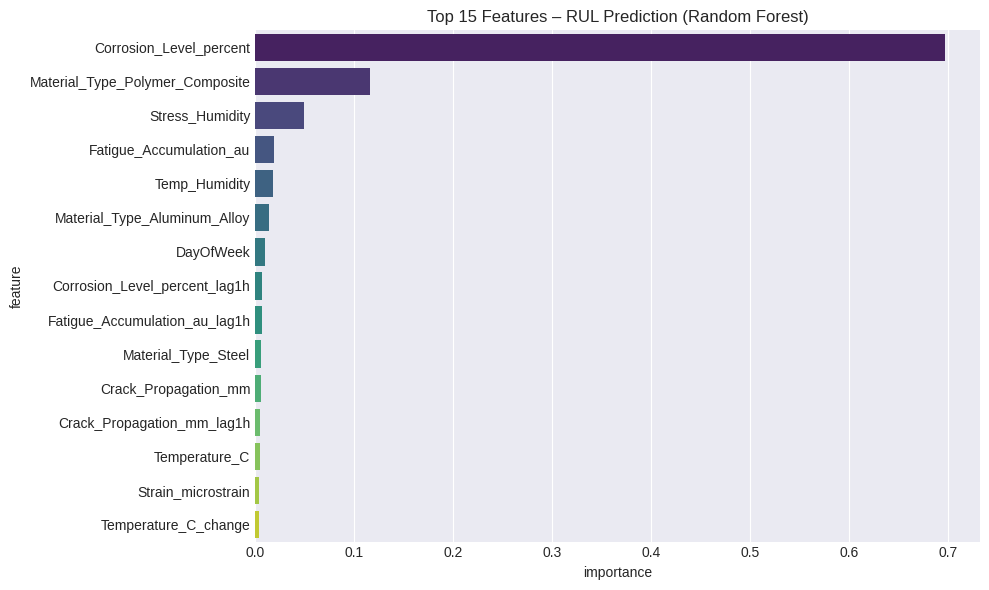

                            feature  importance
10          Corrosion_Level_percent      0.6974
38  Material_Type_Polymer_Composite      0.1155
5                   Stress_Humidity      0.0493
2           Fatigue_Accumulation_au      0.0190
25                    Temp_Humidity      0.0182
37     Material_Type_Aluminum_Alloy      0.0134
4                         DayOfWeek      0.0100
12    Corrosion_Level_percent_lag1h      0.0072
6     Fatigue_Accumulation_au_lag1h      0.0065
39              Material_Type_Steel      0.0055
24             Crack_Propagation_mm      0.0055
29       Crack_Propagation_mm_lag1h      0.0048
21                    Temperature_C      0.0047
32               Strain_microstrain      0.0038
14             Temperature_C_change      0.0034

📊 PREDICTION TEST COMPARISON VISUALIZATION


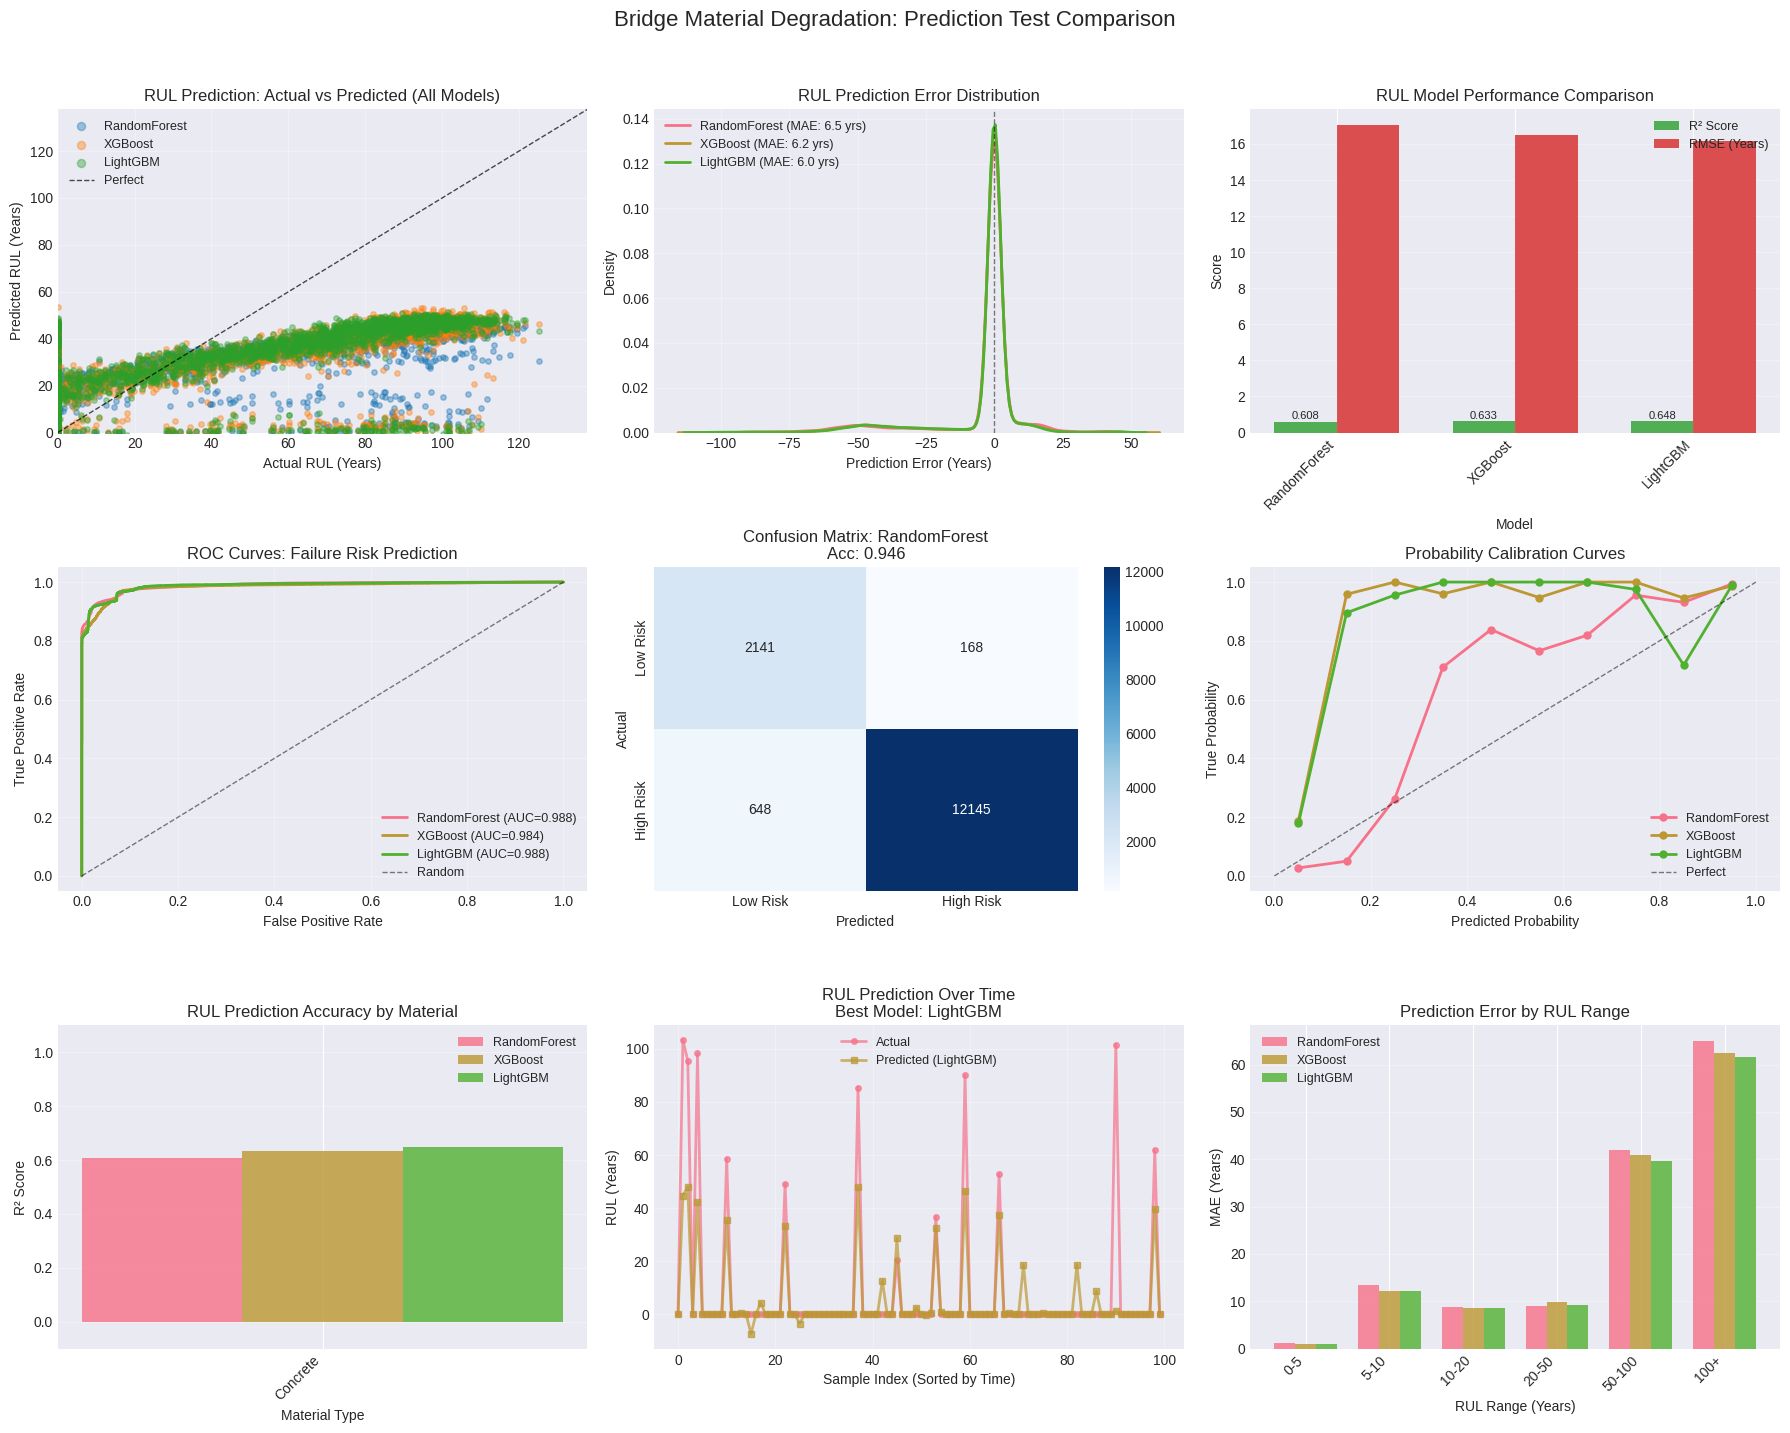


📈 ADDITIONAL STATISTICAL ANALYSIS
Summary Statistics of Predictions (Years):
--------------------------------------------------

Model Comparison (RUL Prediction in Years):
----------------------------------------
       Model  Mean Error  Std Error  Mean Abs Error  Median Abs Error       R²
RandomForest   -4.183138  16.543907        6.513612          0.000000 0.608149
     XGBoost   -4.332317  15.934157        6.211428          0.025022 0.633088
    LightGBM   -4.204791  15.626857        6.022245          0.010613 0.647604

📊 MATERIAL-SPECIFIC ANALYSIS

Mean Absolute Error by Material (Years):
----------------------------------------
Material  Samples  RandomForest_MAE  XGBoost_MAE  LightGBM_MAE
Concrete    15102             6.514        6.211         6.022

🔍 ERROR DISTRIBUTION ANALYSIS

Predictions within ±1 years:
------------------------------
RandomForest   :  77.6%
XGBoost        :  77.4%
LightGBM       :  77.4%

Predictions within ±2 years:
------------------------------
Rando

In [6]:
# ===========================================
# BRIDGE MATERIAL DEGRADATION MONITORING SYSTEM
# Virtual IoT Sensors & Machine Learning for RUL Prediction
# FIXED VERSION – No leakage, corrected imputation
# ===========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ===========================================
# 1. LOAD DATA
# ===========================================
print("📊 Loading Bridge Digital Twin Dataset...")
df = pd.read_csv('/kaggle/input/digital-twin-bridge-structural-health-monitoring/bridge_digital_twin_dataset.csv')
print(f"✅ Dataset loaded | Shape: {df.shape}")

df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp')

print(f"Time range: {df['Timestamp'].min()} → {df['Timestamp'].max()}")

# ===========================================
# 2. SYNTHETIC MATERIAL + DEGRADATION + RUL
# ===========================================
print("\n🏗️ Creating synthetic material & degradation labels...")

materials = ['Steel', 'Concrete', 'Polymer_Composite', 'Aluminum_Alloy']
material_dist = [0.40, 0.35, 0.15, 0.10]

df['Material_Type'] = np.random.choice(materials, size=len(df), p=material_dist)

def calc_degradation_rate(row):
    base = 0.0
    if row['Material_Type'] == 'Steel':
        base = (row.get('Corrosion_Level_percent', 0.15) *
                row.get('Humidity_percent', 65) / 100 *
                (1 + row.get('Salinity_ppm', 0)/10000) *
                (1 + abs(row.get('Temperature_C', 20)-20)/50))
    elif row['Material_Type'] == 'Concrete':
        base = (row.get('Crack_Propagation_mm', 0.15) * 10 *
                (1 + abs(row.get('Temperature_C', 10)-10)/40))
    elif row['Material_Type'] == 'Polymer_Composite':
        base = (row.get('Solar_Radiation_Wm2', 500)/1000 *
                row.get('Humidity_percent', 65)/100 * 0.5)
    else:  # Aluminum
        base = (row.get('Corrosion_Level_percent', 0.1) +
                row.get('Fatigue_Accumulation_au', 0.3)) / 2
    
    stress_factor = 1 + row.get('Stress_Level_MPa', 150) / 500
    return min(max(base * stress_factor, 0), 1)

# Approximate stress if missing
if 'Stress_Level_MPa' not in df.columns and 'Strain_microstrain' in df.columns:
    df['Stress_Level_MPa'] = df['Strain_microstrain'] * 200000 / 1e6  # ~steel

df['Degradation_Rate'] = df.apply(calc_degradation_rate, axis=1)

# Cumulative degradation → only for visualization / label creation
df = df.sort_values(['Material_Type', 'Timestamp'])
df['Cumulative_Degradation'] = df.groupby('Material_Type')['Degradation_Rate'].cumsum() / 100

# RUL calculation
base_lifespans = {
    'Steel': 50*365*24,
    'Concrete': 100*365*24,
    'Polymer_Composite': 30*365*24,
    'Aluminum_Alloy': 40*365*24
}

def calc_rul(row):
    base = base_lifespans.get(row['Material_Type'], 25*365*24)
    consumed = row['Cumulative_Degradation'] * base
    return max(0, base - consumed + np.random.normal(0, base*0.08))

df['RUL_Hours'] = df.apply(calc_rul, axis=1)

def health_status(rul_h):
    if rul_h <= 365*24:     return 'Critical'
    if rul_h <= 5*365*24:   return 'Poor'
    if rul_h <= 15*365*24:  return 'Fair'
    if rul_h <= 30*365*24:  return 'Good'
    return 'Excellent'

df['Health_Status'] = df['RUL_Hours'].apply(health_status)
df['Failure_Risk_High'] = df['Health_Status'].isin(['Critical', 'Poor']).astype(int)

print("\nMaterial distribution:\n", df['Material_Type'].value_counts())
print("\nHealth distribution:\n", df['Health_Status'].value_counts())

# ===========================================
# 3. FEATURE ENGINEERING – NO LEAKAGE
# ===========================================
print("\n⚙️ Feature engineering (leakage-free)...")

df_processed = df.copy()

lag_cols = [
    'Strain_microstrain', 'Deflection_mm', 'Vibration_ms2',
    'Corrosion_Level_percent', 'Crack_Propagation_mm',
    'Fatigue_Accumulation_au', 'Stress_Level_MPa',
    'Temperature_C', 'Humidity_percent'
]

# Create lag-1 and difference features
for col in lag_cols:
    if col in df_processed.columns:
        df_processed[f'{col}_lag1h'] = df_processed.groupby('Material_Type')[col].shift(1)
        df_processed[f'{col}_change'] = df_processed.groupby('Material_Type')[col].diff()

# Simple non-leaking interactions
df_processed['Stress_Humidity'] = df_processed['Stress_Level_MPa'] * df_processed['Humidity_percent'] / 100
df_processed['Temp_Humidity']   = df_processed['Temperature_C'] * df_processed['Humidity_percent']

# Time features
df_processed['Hour']      = df_processed['Timestamp'].dt.hour
df_processed['DayOfWeek'] = df_processed['Timestamp'].dt.dayofweek
df_processed['Month']     = df_processed['Timestamp'].dt.month

# ───────────────────────────────────────────────
# Collect columns that need imputation
# ───────────────────────────────────────────────
impute_cols = lag_cols.copy()

for col in lag_cols:
    lag_name  = f'{col}_lag1h'
    diff_name = f'{col}_change'
    if lag_name  in df_processed.columns: impute_cols.append(lag_name)
    if diff_name in df_processed.columns: impute_cols.append(diff_name)

impute_cols += ['Stress_Humidity', 'Temp_Humidity', 'Hour', 'DayOfWeek', 'Month']

# Remove duplicates & make sure columns exist
impute_cols = list(set(c for c in impute_cols if c in df_processed.columns))

# Impute with median
df_processed[impute_cols] = df_processed[impute_cols].fillna(
    df_processed[impute_cols].median()
)

print(f"Filled missing values in {len(impute_cols)} columns")

# ===========================================
# 4. MODELING FEATURES
# ===========================================
sensor_features = [
    'Strain_microstrain', 'Deflection_mm', 'Vibration_ms2', 'Tilt_deg',
    'Crack_Propagation_mm', 'Corrosion_Level_percent', 'Fatigue_Accumulation_au',
    'Temperature_C', 'Humidity_percent', 'Wind_Speed_ms', 'Solar_Radiation_Wm2',
    'Vehicle_Load_tons', 'Traffic_Volume_vph', 'Stress_Level_MPa'
]

engineered_features = [
    f'{c}_lag1h'  for c in lag_cols if f'{c}_lag1h'  in df_processed.columns
] + [
    f'{c}_change' for c in lag_cols if f'{c}_change' in df_processed.columns
] + [
    'Stress_Humidity', 'Temp_Humidity', 'Hour', 'DayOfWeek', 'Month'
]

modeling_features = [f for f in sensor_features if f in df_processed.columns]
modeling_features += engineered_features
modeling_features += ['Material_Type']

modeling_features = list(set(modeling_features))  # remove possible duplicates

print(f"\nModeling with {len(modeling_features)} features:")
print(", ".join(modeling_features))

# Targets
X = df_processed[modeling_features]
y_rul   = df_processed['RUL_Hours']
y_risk  = df_processed['Failure_Risk_High']
y_health = df_processed['Health_Status']

# ===========================================
# 5. TRAIN/TEST SPLIT – group aware
# ===========================================
print("\n📈 Group-aware train/test split...")

splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(splitter.split(X, groups=df_processed['Material_Type']))

X_train = X.iloc[train_idx]
X_test  = X.iloc[test_idx]

y_rul_train   = y_rul.iloc[train_idx]
y_rul_test    = y_rul.iloc[test_idx]
y_risk_train  = y_risk.iloc[train_idx]
y_risk_test   = y_risk.iloc[test_idx]
y_health_train = y_health.iloc[train_idx]
y_health_test  = y_health.iloc[test_idx]

print(f"Train: {len(X_train):,} samples  |  Test: {len(X_test):,} samples")
print("\nTest set health status distribution:")
print(y_health_test.value_counts(normalize=True).round(3) * 100)

# ===========================================
# 6. PREPROCESSING PIPELINE
# ===========================================
cat_cols = ['Material_Type']
num_cols = [c for c in modeling_features if c not in cat_cols]

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
], remainder='drop')

# ===========================================
# 7. MODEL TRAINING & EVALUATION
# ===========================================
print("\n🤖 Training models...")

reg_models = {
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

clf_models = {
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

# ── Regression ────────────────────────────────────────
reg_results = {}
reg_predictions = {}
for name, model in reg_models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_rul_train)
    
    pred = pipe.predict(X_test)
    reg_predictions[name] = pred
    reg_results[name] = {
        'R²':   r2_score(y_rul_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_rul_test, pred)),
        'MAE':  mean_absolute_error(y_rul_test, pred)
    }
    print(f"{name:12} → R²: {reg_results[name]['R²']:.3f}   RMSE: {reg_results[name]['RMSE']:8.0f} h   MAE: {reg_results[name]['MAE']:7.0f} h")

# ── Binary Classification (High Risk) ─────────────────
clf_results = {}
clf_probabilities = {}
for name, model in clf_models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_risk_train)
    
    pred  = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    clf_probabilities[name] = proba
    
    clf_results[name] = {
        'Accuracy': (pred == y_risk_test).mean(),
        'AUC':      roc_auc_score(y_risk_test, proba) if len(set(y_risk_test)) > 1 else np.nan,
        'F1':       classification_report(y_risk_test, pred, output_dict=True, zero_division=0)['1']['f1-score']
    }
    print(f"{name:12} → Acc: {clf_results[name]['Accuracy']:.3f}   AUC: {clf_results[name]['AUC']:.3f}   F1: {clf_results[name]['F1']:.3f}")

# ── Health Status (multi-class) ───────────────────────
print("\nHealth status classification...")
if len(y_health_test.unique()) > 1:
    le = LabelEncoder()
    y_health_train_enc = le.fit_transform(y_health_train)
    y_health_test_enc  = le.transform(y_health_test)
    
    pipe_health = Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestClassifier(n_estimators=120, random_state=42, n_jobs=-1))
    ])
    pipe_health.fit(X_train, y_health_train_enc)
    
    pred_health = pipe_health.predict(X_test)
    print("\nClassification Report (Health Status):")
    print(classification_report(y_health_test_enc, pred_health,
                                target_names=le.classes_,
                                zero_division=0))
else:
    print("⚠️ Only one class present in test set → skipping multi-class evaluation")

# ===========================================
# 8. FEATURE IMPORTANCE (from best model)
# ===========================================
print("\n🎯 Feature importance (RandomForest Regressor)...")

rf_pipe = Pipeline([('prep', preprocessor),
                    ('model', RandomForestRegressor(n_estimators=80, random_state=42, n_jobs=-1))])
rf_pipe.fit(X_train, y_rul_train)

importances = rf_pipe.named_steps['model'].feature_importances_
feature_names = num_cols + list(rf_pipe.named_steps['prep']
                                .named_transformers_['cat']['onehot']
                                .get_feature_names_out(cat_cols))

fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df, x='importance', y='feature', palette='viridis')
plt.title('Top 15 Features – RUL Prediction (Random Forest)')
plt.tight_layout()
plt.show()

print(fi_df.round(4))

# ===========================================
# 9. PREDICTION TEST COMPARISON VISUALIZATION
# ===========================================
print("\n" + "="*60)
print("📊 PREDICTION TEST COMPARISON VISUALIZATION")
print("="*60)

def plot_prediction_comparisons():
    """Create comprehensive visualization of model predictions"""
    
    fig = plt.figure(figsize=(18, 14))
    
    # 1. RUL Prediction Comparison (All Models)
    ax1 = plt.subplot(3, 3, 1)
    colors = {'RandomForest': '#1f77b4', 'XGBoost': '#ff7f0e', 'LightGBM': '#2ca02c'}
    
    for model_name, pred in reg_predictions.items():
        ax1.scatter(y_rul_test.values / (24*365), pred / (24*365), 
                   alpha=0.4, s=15, label=model_name, color=colors.get(model_name, 'gray'))
    
    # Perfect prediction line
    max_val = max(y_rul_test.max(), max([p.max() for p in reg_predictions.values()])) / (24*365)
    ax1.plot([0, max_val*1.1], [0, max_val*1.1], 'k--', linewidth=1, alpha=0.7, label='Perfect')
    
    ax1.set_xlabel('Actual RUL (Years)', fontsize=10)
    ax1.set_ylabel('Predicted RUL (Years)', fontsize=10)
    ax1.set_title('RUL Prediction: Actual vs Predicted (All Models)', fontsize=12)
    ax1.legend(fontsize=9, markerscale=1.5)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, max_val*1.1)
    ax1.set_ylim(0, max_val*1.1)
    
    # 2. RUL Error Distribution by Model
    ax2 = plt.subplot(3, 3, 2)
    errors_by_model = {}
    for model_name, pred in reg_predictions.items():
        error_years = (pred - y_rul_test.values) / (24*365)
        errors_by_model[model_name] = error_years
        
        # Plot histogram
        sns.kdeplot(error_years, ax=ax2, label=f"{model_name} (MAE: {np.mean(np.abs(error_years)):.1f} yrs)", 
                   linewidth=2)
    
    ax2.axvline(x=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
    ax2.set_xlabel('Prediction Error (Years)', fontsize=10)
    ax2.set_ylabel('Density', fontsize=10)
    ax2.set_title('RUL Prediction Error Distribution', fontsize=12)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    # 3. Model Performance Comparison (RUL)
    ax3 = plt.subplot(3, 3, 3)
    model_names = list(reg_results.keys())
    r2_scores = [reg_results[m]['R²'] for m in model_names]
    rmse_scores = [reg_results[m]['RMSE']/(24*365) for m in model_names]  # Convert to years
    
    x = np.arange(len(model_names))
    width = 0.35
    
    bars1 = ax3.bar(x - width/2, r2_scores, width, label='R² Score', color='#2ca02c', alpha=0.8)
    bars2 = ax3.bar(x + width/2, rmse_scores, width, label='RMSE (Years)', color='#d62728', alpha=0.8)
    
    ax3.set_xlabel('Model', fontsize=10)
    ax3.set_ylabel('Score', fontsize=10)
    ax3.set_title('RUL Model Performance Comparison', fontsize=12)
    ax3.set_xticks(x)
    ax3.set_xticklabels(model_names, rotation=45, ha='right')
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar in bars1:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)
    
    # 4. ROC Curves Comparison (Risk Classification)
    ax4 = plt.subplot(3, 3, 4)
    for model_name, proba in clf_probabilities.items():
        if len(set(y_risk_test)) > 1:
            fpr, tpr, _ = roc_curve(y_risk_test, proba)
            auc_score = roc_auc_score(y_risk_test, proba)
            ax4.plot(fpr, tpr, label=f'{model_name} (AUC={auc_score:.3f})', linewidth=2)
    
    ax4.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random')
    ax4.set_xlabel('False Positive Rate', fontsize=10)
    ax4.set_ylabel('True Positive Rate', fontsize=10)
    ax4.set_title('ROC Curves: Failure Risk Prediction', fontsize=12)
    ax4.legend(fontsize=9)
    ax4.grid(True, alpha=0.3)
    
    # 5. Confusion Matrix for Best Classifier
    ax5 = plt.subplot(3, 3, 5)
    best_clf_model = max(clf_results.items(), key=lambda x: x[1]['AUC'])[0]
    best_clf_pipe = Pipeline([('prep', preprocessor), ('model', clf_models[best_clf_model])])
    best_clf_pipe.fit(X_train, y_risk_train)
    y_pred_best = best_clf_pipe.predict(X_test)
    
    cm = confusion_matrix(y_risk_test, y_pred_best)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax5,
                xticklabels=['Low Risk', 'High Risk'],
                yticklabels=['Low Risk', 'High Risk'])
    ax5.set_xlabel('Predicted', fontsize=10)
    ax5.set_ylabel('Actual', fontsize=10)
    ax5.set_title(f'Confusion Matrix: {best_clf_model}\nAcc: {clf_results[best_clf_model]["Accuracy"]:.3f}', fontsize=12)
    
    # 6. Probability Calibration Plot
    ax6 = plt.subplot(3, 3, 6)
    for model_name, proba in clf_probabilities.items():
        # Bin probabilities and compute average true probability
        bins = np.linspace(0, 1, 11)
        bin_centers = (bins[:-1] + bins[1:]) / 2
        bin_indices = np.digitize(proba, bins) - 1
        
        true_probs = []
        for i in range(len(bins)-1):
            mask = bin_indices == i
            if mask.sum() > 0:
                true_probs.append(y_risk_test[mask].mean())
            else:
                true_probs.append(np.nan)
        
        ax6.plot(bin_centers, true_probs, 'o-', label=model_name, linewidth=2, markersize=5)
    
    ax6.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Perfect')
    ax6.set_xlabel('Predicted Probability', fontsize=10)
    ax6.set_ylabel('True Probability', fontsize=10)
    ax6.set_title('Probability Calibration Curves', fontsize=12)
    ax6.legend(fontsize=9)
    ax6.grid(True, alpha=0.3)
    
    # 7. Material-Specific Prediction Accuracy
    ax7 = plt.subplot(3, 3, 7)
    materials = X_test['Material_Type'].unique()
    material_r2 = {model: [] for model in reg_models.keys()}
    
    for material in materials:
        mask = X_test['Material_Type'] == material
        if mask.sum() > 5:  # Require minimum samples
            for model_name, pred in reg_predictions.items():
                material_actual = y_rul_test[mask].values
                material_pred = pred[mask]
                r2 = r2_score(material_actual, material_pred) if len(material_actual) > 1 else np.nan
                material_r2[model_name].append(r2)
    
    x = np.arange(len(materials))
    width = 0.25
    for idx, (model_name, r2_vals) in enumerate(material_r2.items()):
        ax7.bar(x + idx*width - width, r2_vals, width, label=model_name, alpha=0.8)
    
    ax7.set_xlabel('Material Type', fontsize=10)
    ax7.set_ylabel('R² Score', fontsize=10)
    ax7.set_title('RUL Prediction Accuracy by Material', fontsize=12)
    ax7.set_xticks(x)
    ax7.set_xticklabels(materials, rotation=45, ha='right')
    ax7.legend(fontsize=9)
    ax7.grid(True, alpha=0.3, axis='y')
    ax7.set_ylim(-0.1, 1.1)
    
    # 8. Prediction vs Time (Sample)
    ax8 = plt.subplot(3, 3, 8)
    # Take a sample of 100 points for clarity
    sample_idx = np.random.choice(len(X_test), min(100, len(X_test)), replace=False)
    sample_times = df_processed.iloc[test_idx].iloc[sample_idx]['Timestamp'].sort_values()
    
    # Get indices for sorted times
    sorted_idx = sample_idx[np.argsort(sample_times)]
    
    # Plot actual and predicted for best model
    best_reg_model = max(reg_results.items(), key=lambda x: x[1]['R²'])[0]
    
    ax8.plot(range(len(sorted_idx)), y_rul_test.iloc[sorted_idx].values / (24*365), 
            'o-', label='Actual', linewidth=2, markersize=4, alpha=0.7)
    ax8.plot(range(len(sorted_idx)), reg_predictions[best_reg_model][sorted_idx] / (24*365),
            's-', label=f'Predicted ({best_reg_model})', linewidth=2, markersize=4, alpha=0.7)
    
    ax8.set_xlabel('Sample Index (Sorted by Time)', fontsize=10)
    ax8.set_ylabel('RUL (Years)', fontsize=10)
    ax8.set_title(f'RUL Prediction Over Time\nBest Model: {best_reg_model}', fontsize=12)
    ax8.legend(fontsize=9)
    ax8.grid(True, alpha=0.3)
    
    # 9. Error Analysis by RUL Range
    ax9 = plt.subplot(3, 3, 9)
    # Create RUL bins
    rul_bins = [0, 5, 10, 20, 50, 100, 200]  # In years
    rul_bin_labels = ['0-5', '5-10', '10-20', '20-50', '50-100', '100+']
    
    # Calculate MAE for each bin
    mae_by_bin = {model_name: [] for model_name in reg_models.keys()}
    
    for i in range(len(rul_bins)-1):
        lower = rul_bins[i] * 24 * 365
        upper = rul_bins[i+1] * 24 * 365 if i < len(rul_bins)-2 else np.inf
        
        mask = (y_rul_test >= lower) & (y_rul_test < upper)
        if mask.sum() > 0:
            for model_name, pred in reg_predictions.items():
                mae = mean_absolute_error(y_rul_test[mask], pred[mask]) / (24*365)
                mae_by_bin[model_name].append(mae)
        else:
            for model_name in reg_models.keys():
                mae_by_bin[model_name].append(np.nan)
    
    x = np.arange(len(rul_bin_labels))
    width = 0.25
    for idx, (model_name, mae_vals) in enumerate(mae_by_bin.items()):
        ax9.bar(x + idx*width - width, mae_vals, width, label=model_name, alpha=0.8)
    
    ax9.set_xlabel('RUL Range (Years)', fontsize=10)
    ax9.set_ylabel('MAE (Years)', fontsize=10)
    ax9.set_title('Prediction Error by RUL Range', fontsize=12)
    ax9.set_xticks(x)
    ax9.set_xticklabels(rul_bin_labels, rotation=45, ha='right')
    ax9.legend(fontsize=9)
    ax9.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle('Bridge Material Degradation: Prediction Test Comparison', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Generate the comprehensive comparison plots
plot_prediction_comparisons()

# ===========================================
# 10. ADDITIONAL STATISTICAL ANALYSIS
# ===========================================
print("\n" + "="*60)
print("📈 ADDITIONAL STATISTICAL ANALYSIS")
print("="*60)

# Create a comparison dataframe
comparison_df = pd.DataFrame({
    'Actual_RUL': y_rul_test.values / (24*365),  # Convert to years
    'Material_Type': X_test['Material_Type'].values
})

# Add predictions from each model
for model_name, pred in reg_predictions.items():
    comparison_df[f'Pred_{model_name}'] = pred / (24*365)  # Convert to years

# Calculate errors
for model_name in reg_models.keys():
    comparison_df[f'Error_{model_name}'] = comparison_df[f'Pred_{model_name}'] - comparison_df['Actual_RUL']
    comparison_df[f'AbsError_{model_name}'] = np.abs(comparison_df[f'Error_{model_name}'])

print("Summary Statistics of Predictions (Years):")
print("-" * 50)

# Print model comparison statistics
print("\nModel Comparison (RUL Prediction in Years):")
print("-" * 40)

stats_data = []
for model_name in reg_models.keys():
    stats = {
        'Model': model_name,
        'Mean Error': comparison_df[f'Error_{model_name}'].mean(),
        'Std Error': comparison_df[f'Error_{model_name}'].std(),
        'Mean Abs Error': comparison_df[f'AbsError_{model_name}'].mean(),
        'Median Abs Error': comparison_df[f'AbsError_{model_name}'].median(),
        'R²': reg_results[model_name]['R²']
    }
    stats_data.append(stats)

stats_df = pd.DataFrame(stats_data)
print(stats_df.to_string(index=False))

# Material-specific analysis
print("\n" + "="*60)
print("📊 MATERIAL-SPECIFIC ANALYSIS")
print("="*60)

print("\nMean Absolute Error by Material (Years):")
print("-" * 40)

material_stats = []
for material in materials:
    mask = comparison_df['Material_Type'] == material
    if mask.sum() > 0:
        row = {'Material': material, 'Samples': mask.sum()}
        for model_name in reg_models.keys():
            mae = comparison_df.loc[mask, f'AbsError_{model_name}'].mean()
            row[f'{model_name}_MAE'] = mae
        material_stats.append(row)

material_df = pd.DataFrame(material_stats)
print(material_df.round(3).to_string(index=False))

# Error distribution analysis
print("\n" + "="*60)
print("🔍 ERROR DISTRIBUTION ANALYSIS")
print("="*60)

# Calculate percentage of predictions within certain error bounds
error_bounds = [1, 2, 5, 10]  # Years

for bound in error_bounds:
    print(f"\nPredictions within ±{bound} years:")
    print("-" * 30)
    for model_name in reg_models.keys():
        within_bound = (comparison_df[f'AbsError_{model_name}'] <= bound).mean() * 100
        print(f"{model_name:15}: {within_bound:5.1f}%")

# Best model identification
best_reg_model = max(reg_results.items(), key=lambda x: x[1]['R²'])[0]
best_clf_model = max(clf_results.items(), key=lambda x: x[1]['AUC'] if not np.isnan(x[1]['AUC']) else 0)[0]

print("\n" + "="*60)
print("🏆 BEST MODEL SELECTION")
print("="*60)
print(f"Best RUL Model: {best_reg_model}")
print(f"  - R²: {reg_results[best_reg_model]['R²']:.4f}")
print(f"  - RMSE: {reg_results[best_reg_model]['RMSE']/(24*365):.1f} years")
print(f"  - MAE: {reg_results[best_reg_model]['MAE']/(24*365):.1f} years")

print(f"\nBest Risk Classification Model: {best_clf_model}")
print(f"  - Accuracy: {clf_results[best_clf_model]['Accuracy']:.4f}")
print(f"  - AUC: {clf_results[best_clf_model]['AUC']:.4f}")
print(f"  - F1-Score: {clf_results[best_clf_model]['F1']:.4f}")

# Save predictions for further analysis
print("\n" + "="*60)
print("💾 SAVING PREDICTIONS")
print("="*60)

# Save comparison dataframe
comparison_df.to_csv('prediction_comparison_results.csv', index=False)
print("✅ Predictions saved to 'prediction_comparison_results.csv'")

# Save model metrics
metrics_summary = {
    'regression_models': reg_results,
    'classification_models': clf_results,
    'best_reg_model': best_reg_model,
    'best_clf_model': best_clf_model,
    'feature_count': len(modeling_features),
    'train_samples': len(X_train),
    'test_samples': len(X_test)
}

import json
with open('model_metrics_summary.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2, default=str)

print("✅ Model metrics saved to 'model_metrics_summary.json'")

print("\n" + "="*60)
print("✅ BRIDGE MATERIAL DEGRADATION ANALYSIS COMPLETE!")
print("="*60)
print(f"\n📊 Results Summary:")
print(f"  - Models trained: {len(reg_models)} regression, {len(clf_models)} classification")
print(f"  - Best RUL model: {best_reg_model} (R²: {reg_results[best_reg_model]['R²']:.3f})")
print(f"  - Best Risk model: {best_clf_model} (AUC: {clf_results[best_clf_model]['AUC']:.3f})")
print(f"  - Features used: {len(modeling_features)}")
print(f"  - Test set size: {len(X_test):,} samples")
print(f"  - Files saved: prediction_comparison_results.csv, model_metrics_summary.json")